# UHI vs MBES Comparison with Exact Footprint Masking

This notebook compares UHI (hyperspectral) data with MBES (multibeam echosounder) bathymetry data using **vectorized pixel-perfect masking** (no bounding boxes!).

## Workflow:

1. **Load UHI data** - Load georeferenced UHI transect and select file range
2. **Apply illumination correction** - Correct for illumination effects
3. **Plot UHI georeferencing** - Visualize UHI coverage in NED coordinates
4. **Load and detrend MBES** - Load MBES GeoTIFF and remove systematic trends
5. **Extract UHI coordinates in UTM** - Convert UHI pixel locations to same CRS as MBES
6. **Create vectorized footprint mask** - Map each UHI pixel to exact MBES grid cell
7. **Compare side-by-side** - Show full MBES vs. UHI-masked MBES
8. **Extract values for comparison** - Get MBES depth values at UHI locations
9. **Statistical comparison** - Histogram and statistics

## Key Features:

✅ **No bounding box artifacts** - Uses vectorized coordinate transformation  
✅ **Exact pixel mapping** - Each UHI sample maps to precise MBES pixel  
✅ **Preserves UHI footprint shape** - Masked MBES shows same ragged edges as UHI  
✅ **Fast vectorized operation** - No loops over individual points


In [1]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils import georef
import config

# IMPORTANT: Reload the module to get the latest changes (track_start/track_end parameters)
importlib.reload(georef)
from utils.georef import *

print("✅ Module reloaded successfully!")

✅ Module reloaded successfully!


In [2]:
# Load transect from the output folder specified in config
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()

%matplotlib inline



📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)

=== Combined_output ===
Tracks × Slits: 4925 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_4: tracks 0–2462 (2463)
  rad_uhi_20241029_115057_5: tracks 

In [4]:
# cube.apply_illumination_correction(window_size=1000)
cube.apply_illumination_correction(window_size=None)

🔄 Applying illumination correction: global, strength=1.0


   Processing slits: 100%|██████████| 968/968 [03:13<00:00,  5.00slit/s]

✅ data_corrected ready (global)


array([[[0.0000000e+00, 1.0000000e+00, 1.7476670e+00, ...,
         0.0000000e+00, 5.7710009e+00, 0.0000000e+00],
        [2.8876233e-01, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 3.9922733e+00, 0.0000000e+00],
        [1.5649713e+00, 1.2371542e+00, 1.8438836e+00, ...,
         0.0000000e+00, 8.4467888e+00, 0.0000000e+00],
        ...,
        [6.9230771e-01, 2.5122850e+00, 1.2166845e+00, ...,
         0.0000000e+00, 3.2556582e-02, 0.0000000e+00],
        [1.6596318e+00, 0.0000000e+00, 7.4293053e-01, ...,
         0.0000000e+00, 4.1941214e+00, 0.0000000e+00],
        [1.6375221e+00, 4.3093687e-01, 2.1612904e+00, ...,
         0.0000000e+00, 2.6945860e+01, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 1.0532753e+01, ...,
         0.0000000e+00, 5.5801611e+00, 0.0000000e+00],
        [0.0000000e+00, 6.7373520e-01, 1.1941750e+00, ...,
         0.0000000e+00, 3.3165989e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         4.037

  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
📊 Plotting tracks 3039–4028 (shape: 990 × 968)
💡 Interactive mode: Click on the plot to display coordinates
📊 Plotting tracks 3039–4028 (shape: 990 × 968)
💡 Interactive mode: Click on the plot to display coordinates


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:675: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:783: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:783: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


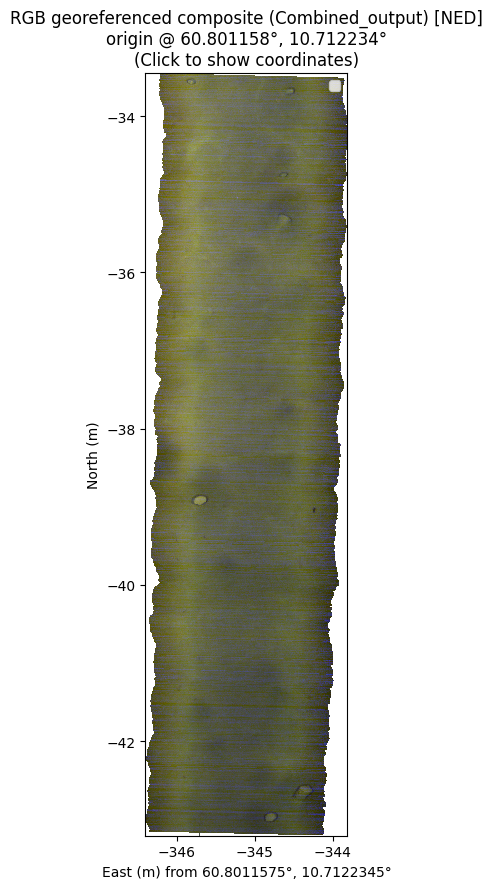

📊 Plotting tracks 3039–4028 (shape: 990 × 968)
💡 Interactive mode: Click on the plot to display coordinates


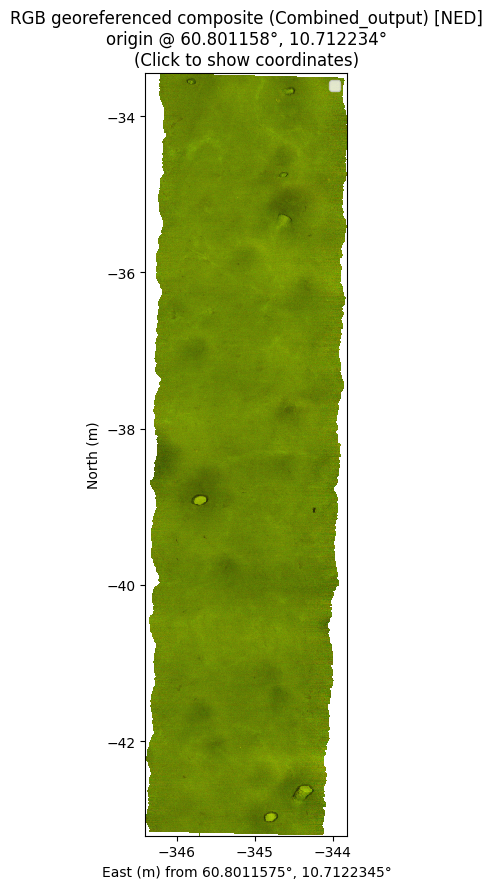

In [4]:
track_start = 3039
track_end = 4029
cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=3039,
    track_end=4029,
)

cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=3039,
    track_end=4029,
    use_corrected=True,  # ← NEW PARAMETER!
)

In [5]:
# ========== LOAD MBES DATA AND DETREND ==========
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "dev"))
from dev3_mbes2 import MBESDetrender, extract_uhi_coordinates_from_cube

# Load and detrend MBES
print("\n📂 Loading MBES GeoTIFF...")
mb = MBESDetrender(
    config.MBES_GEOTIFF,
    crop_start_m=1.0,  # Crop 1m from start (bottom in image)
    crop_end_m=10.0,  # Crop 10m from end (top in image)
).load()

print(f"   Shape: {mb.data.shape}")
print(f"   Resolution: {mb.px_x:.4f} × {mb.px_y:.4f} m")

# Detrend
print("\n⚙️  Detrending MBES...")
mb.detrend(
    order_x=4,
    smooth_baseline_m=0.1,
    smooth_tilt_m=0.1,
    smooth_center_m=1,
    central_frac=0.8,
    robust=True,
)
print("   ✅ Detrending complete!")


📂 Loading MBES GeoTIFF...
   Shape: (5249, 1408)
   Resolution: 0.0200 × 0.0200 m

⚙️  Detrending MBES...
   ✅ Detrending complete!
   ✅ Detrending complete!


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\dev\dev3_mbes2.py:351: RuntimeWarning: invalid value encountered in divide
  result = np.where(mask_smoothed > 0.01, smoothed / mask_smoothed, np.nan)


In [6]:
# ========== EXTRACT UHI COORDINATES IN UTM (SAME CRS AS MBES) ==========
print("\n🗺️  Extracting UHI coordinates in UTM...")
uhi_x_utm, uhi_y_utm = extract_uhi_coordinates_from_cube(
    cube,
    track_start=track_start,
    track_end=track_end,
    coordinate_system="UTM",
    epsg_utm=config.EPSG_MBES,  # Make sure UHI coords are in same CRS as MBES
)

print(f"   UHI coord arrays shape: {uhi_x_utm.shape}")
print(f"   X range: [{np.nanmin(uhi_x_utm):.1f}, {np.nanmax(uhi_x_utm):.1f}] m")
print(f"   Y range: [{np.nanmin(uhi_y_utm):.1f}, {np.nanmax(uhi_y_utm):.1f}] m")
print(f"   Valid pixels: {np.sum(np.isfinite(uhi_x_utm)):,}")


🗺️  Extracting UHI coordinates in UTM...
   Converting 958,320 UHI pixels ECEF → UTM (EPSG:32632)...
   UHI coord arrays shape: (990, 968)
   UHI coord arrays shape: (990, 968)
   X range: [592833.6, 592836.0] m
   Y range: [6741803.0, 6741812.7] m
   Valid pixels: 958,320
   X range: [592833.6, 592836.0] m
   Y range: [6741803.0, 6741812.7] m
   Valid pixels: 958,320



🎨 Creating side-by-side comparison...

🎭 Creating UHI footprint comparison...
   Building vectorized UHI footprint mask...
   ✅ Mask created: 57,067/7,390,592 MBES pixels covered (0.77%)

📊 Comparison Stats:
   Display region: [592828.6, 592841.0] × [6741798.0, 6741817.7] m
   UHI coverage in view: 57,067 pixels
   Valid MBES data in UHI footprint: 57,067 pixels


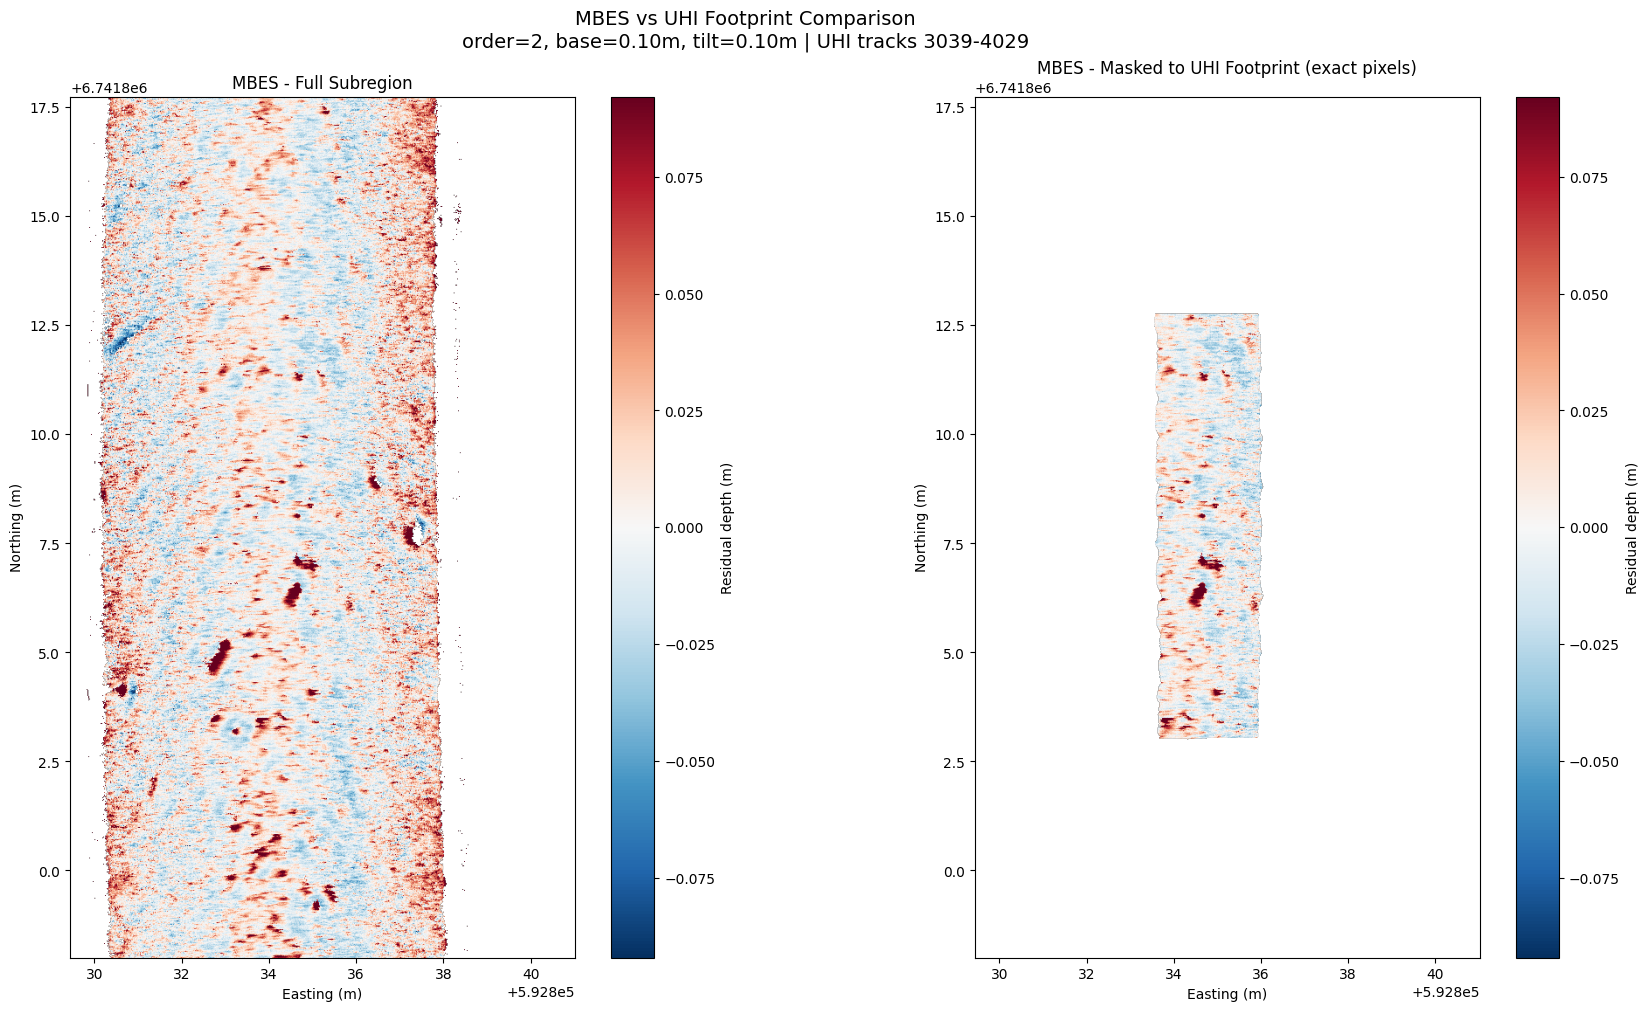

In [7]:
# ========== COMPARE: FULL MBES vs. UHI-MASKED MBES ==========
print("\n🎨 Creating side-by-side comparison...")
fig_comparison, uhi_mask = mb.compare_with_uhi_footprint(
    uhi_x_utm,
    uhi_y_utm,
    buffer_m=5.0,  # Add 5m buffer around UHI extent for display
    figsize=(18, 10),
    cmap="RdBu_r",
    vmax=None,  # Auto-scale
    title_suffix=f"UHI tracks {track_start}-{track_end}",
)

# The left panel shows the full MBES subregion
# The right panel shows only MBES pixels where UHI data exists (exact pixel mapping!)

In [8]:
# ========== OPTIONAL: Extract MBES values at UHI locations for quantitative comparison ==========
# Get MBES residual values at each UHI pixel location
print("\n📊 Extracting MBES values at UHI locations...")

# Flatten UHI coordinates
uhi_x_flat = uhi_x_utm.ravel()
uhi_y_flat = uhi_y_utm.ravel()
valid = np.isfinite(uhi_x_flat) & np.isfinite(uhi_y_flat)
uhi_x_valid = uhi_x_flat[valid]
uhi_y_valid = uhi_y_flat[valid]

# Convert UHI world coords to MBES pixel indices
col0_left = mb.x_cols[0] - mb.px_x * 0.5
row0_top = mb.y_rows[0] + mb.px_y * 0.5

cols = np.floor((uhi_x_valid - col0_left) / mb.px_x).astype(int)
rows = np.floor((row0_top - uhi_y_valid) / mb.px_y).astype(int)

# Keep only points inside MBES grid
H, W = mb.residuals.shape
valid_indices = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)
rows_valid = rows[valid_indices]
cols_valid = cols[valid_indices]

# Extract MBES values
mbes_values_at_uhi = mb.residuals[rows_valid, cols_valid]
valid_comparison = np.isfinite(mbes_values_at_uhi)

print(f"   UHI pixels: {len(uhi_x_valid):,}")
print(f"   Inside MBES grid: {len(rows_valid):,}")
print(f"   With valid MBES data: {np.sum(valid_comparison):,}")
print(f"\n   MBES residuals at UHI locations:")
print(f"      Mean: {np.nanmean(mbes_values_at_uhi):.3f} m")
print(f"      Std:  {np.nanstd(mbes_values_at_uhi):.3f} m")
print(f"      Min:  {np.nanmin(mbes_values_at_uhi):.3f} m")
print(f"      Max:  {np.nanmax(mbes_values_at_uhi):.3f} m")


📊 Extracting MBES values at UHI locations...
   UHI pixels: 958,320
   Inside MBES grid: 958,320
   With valid MBES data: 958,320

   MBES residuals at UHI locations:
      Mean: 0.002 m
      Std:  0.024 m
      Min:  -0.064 m
      Max:  0.229 m


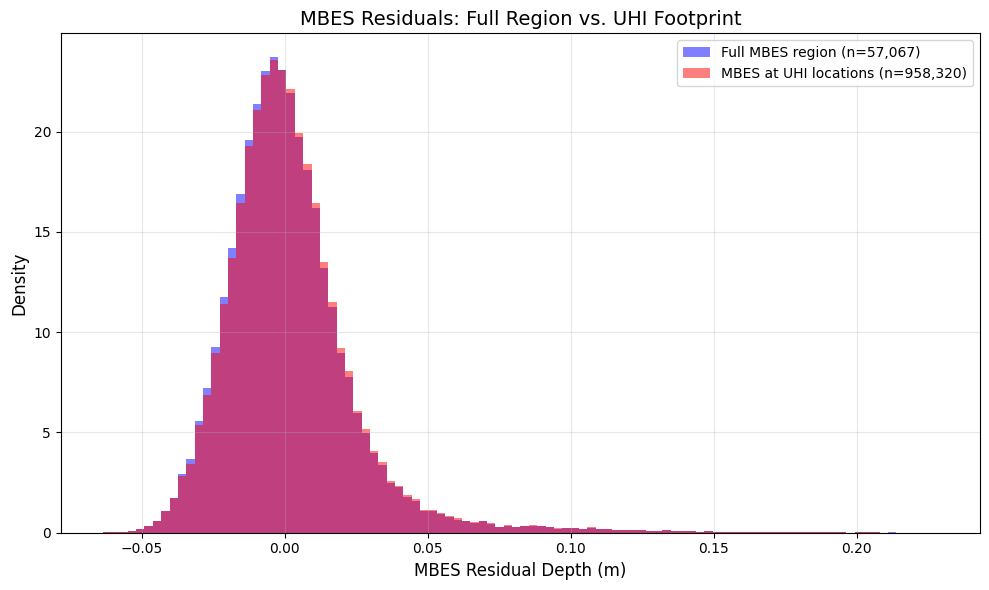


✅ Comparison complete!

Now you can:
  1. Compare UHI depth measurements with mbes_values_at_uhi
  2. Compute differences, correlations, etc.
  3. The 'uhi_mask' variable is a boolean mask you can use for any MBES array


In [9]:
# ========== HISTOGRAM: Compare full MBES vs. UHI-masked region ==========
import matplotlib.pyplot as plt

fig_hist, ax = plt.subplots(figsize=(10, 6))

# Full MBES residuals in the displayed region
mbes_all = mb.residuals[uhi_mask].ravel()
mbes_all = mbes_all[np.isfinite(mbes_all)]

# MBES values only where UHI exists
mbes_at_uhi_clean = mbes_values_at_uhi[valid_comparison]

ax.hist(
    mbes_all,
    bins=100,
    alpha=0.5,
    label=f"Full MBES region (n={len(mbes_all):,})",
    color="blue",
    density=True,
)
ax.hist(
    mbes_at_uhi_clean,
    bins=100,
    alpha=0.5,
    label=f"MBES at UHI locations (n={len(mbes_at_uhi_clean):,})",
    color="red",
    density=True,
)

ax.set_xlabel("MBES Residual Depth (m)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("MBES Residuals: Full Region vs. UHI Footprint", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Comparison complete!")
print("\nNow you can:")
print("  1. Compare UHI depth measurements with mbes_values_at_uhi")
print("  2. Compute differences, correlations, etc.")
print("  3. The 'uhi_mask' variable is a boolean mask you can use for any MBES array")